field cardinality : 18446744073709551629
running time of insecure controller: 1.9870965480804443 s
running time of secure controller: 21.19652533531189 s
running time of secure /running time of insecure : 10.66708376892303
+------------------+-------------------------------------+-------------------------------------------+-----------+-----------------+---------------------+
|      Signal      |    Integral Absolute Error(IAE)     |        Integral Squared Error(ISE)        | Open Loop | Closed Loop/PID | Closed Loop/MPC-PID |
|                  | sum[abs(insecureX-secureX)]/samples | sum[abs(sqrt(insecureX-secureX))]/samples |           |                 |                     |
+------------------+-------------------------------------+-------------------------------------------+-----------+-----------------+---------------------+
|        x1        |              5.766E-05              |                 5.261E-09                 | 2.180E-04 |    2.877E-05    |      2.869E-05      |
| 

/opt/sagemath-9.1/local/lib/python3.7/site-packages/scipy/io/matlab/mio5.py:809: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  self.file_stream.write(hdr.tostring())
/opt/sagemath-9.1/local/lib/python3.7/site-packages/scipy/io/matlab/mio5.py:480: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  self.file_stream.write(arr.tostring(order='F'))
/opt/sagemath-9.1/local/lib/python3.7/site-packages/scipy/io/matlab/mio5.py:503: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  tag['data'] = arr.tostring(order='F')
/opt/sagemath-9.1/local/lib/python3.7/site-packages/matplotlib/axes/_base.py:3157: UserWarning: Attempted to set non-positive xlimits for log-scale axis; invalid limits will be ignored.
  'Attempted to set non-positive xlimits for log-scale axis; '
/opt/sagemath-9.1/local/lib/python3.7/site-packages/matplotlib/axes/_base.py:3157: UserWarning: Attempted to set non-positive xlimits for log-scale axis; invalid limits w

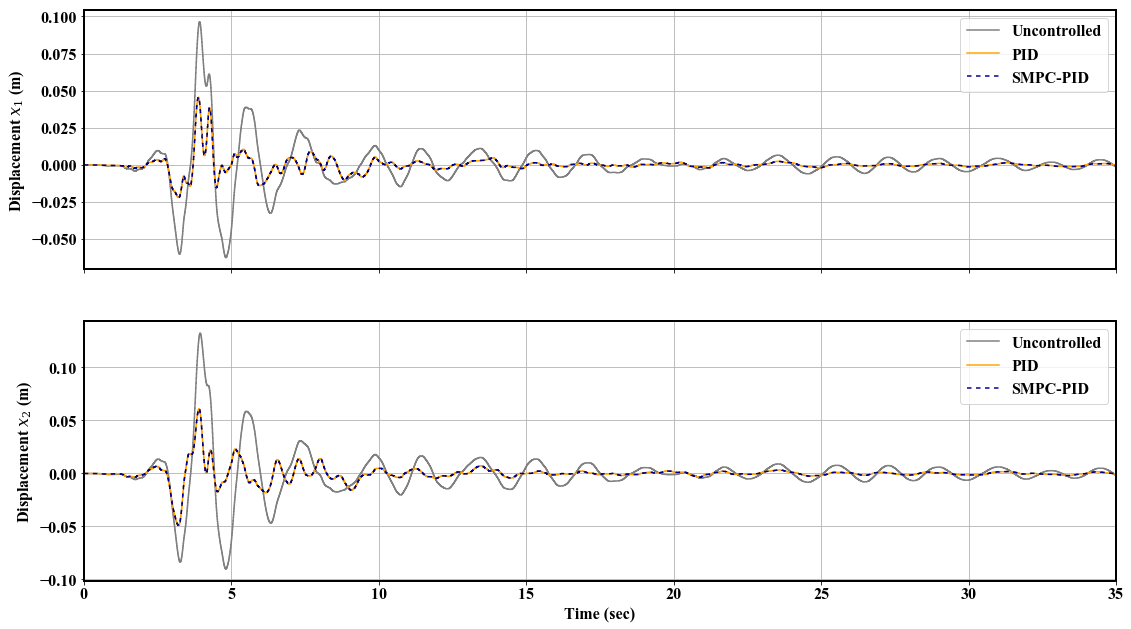

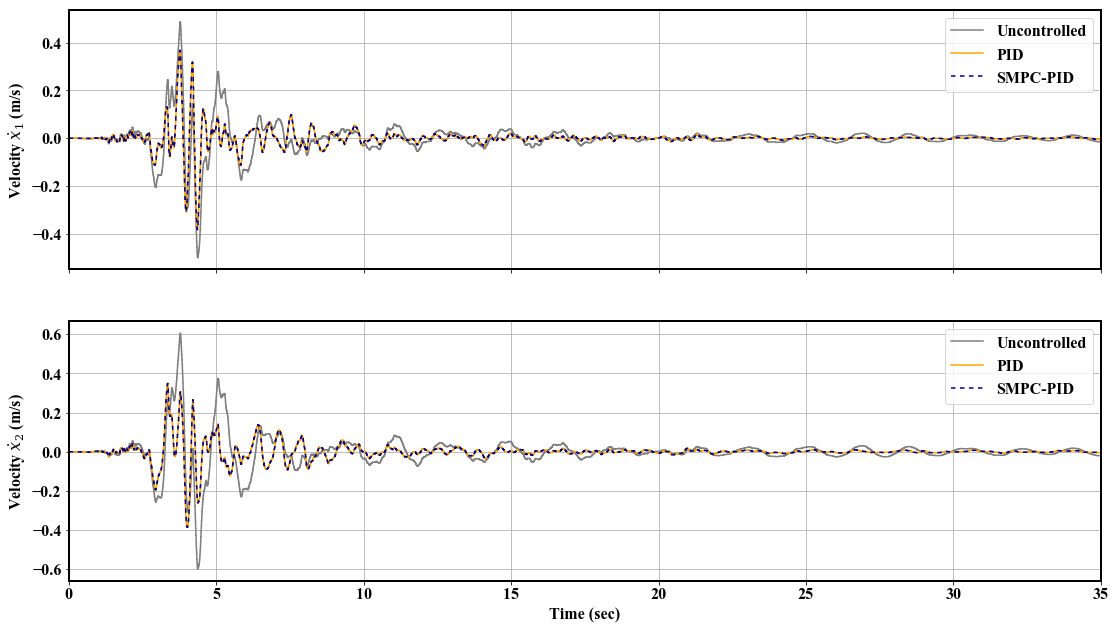

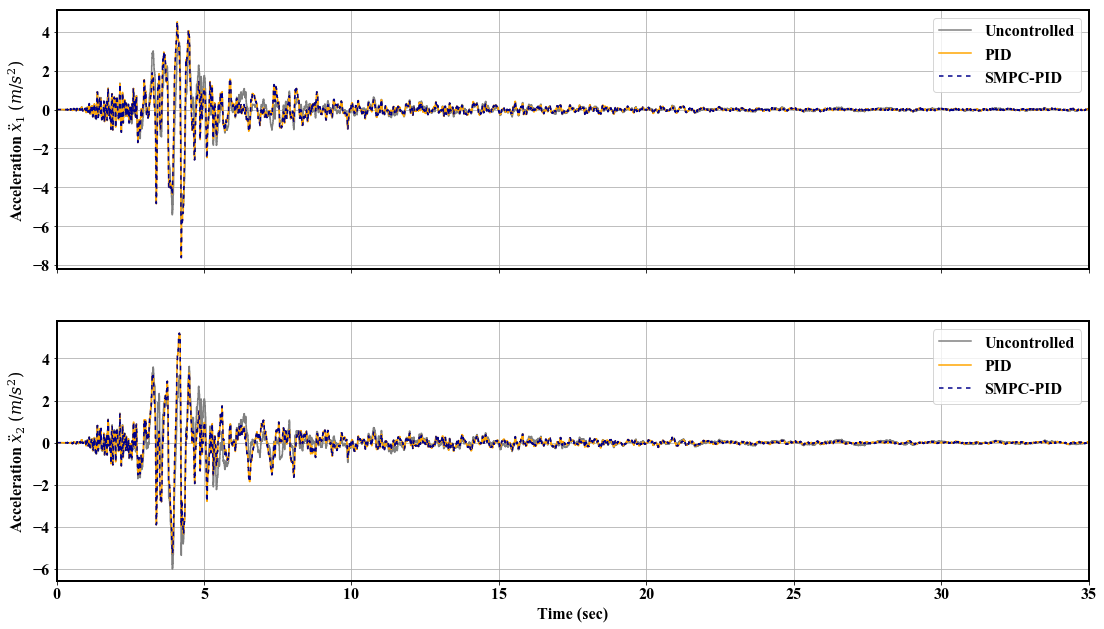

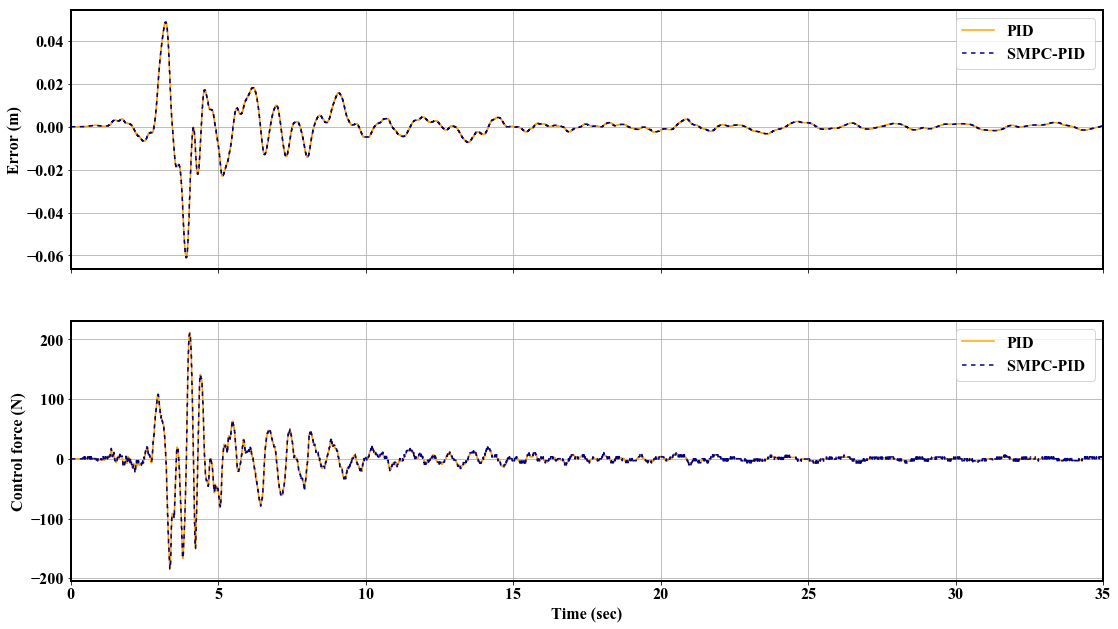

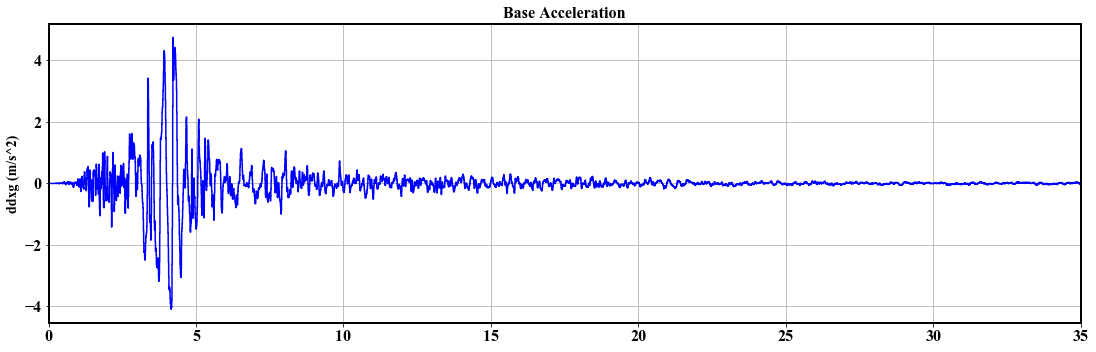

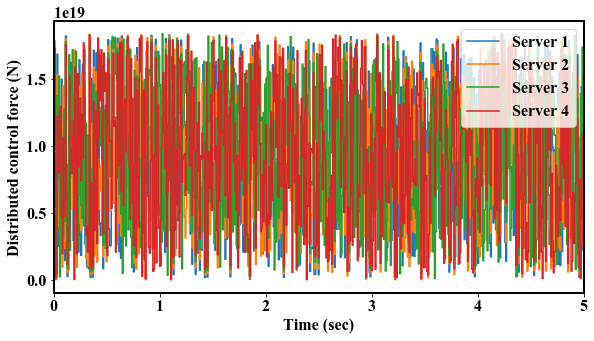

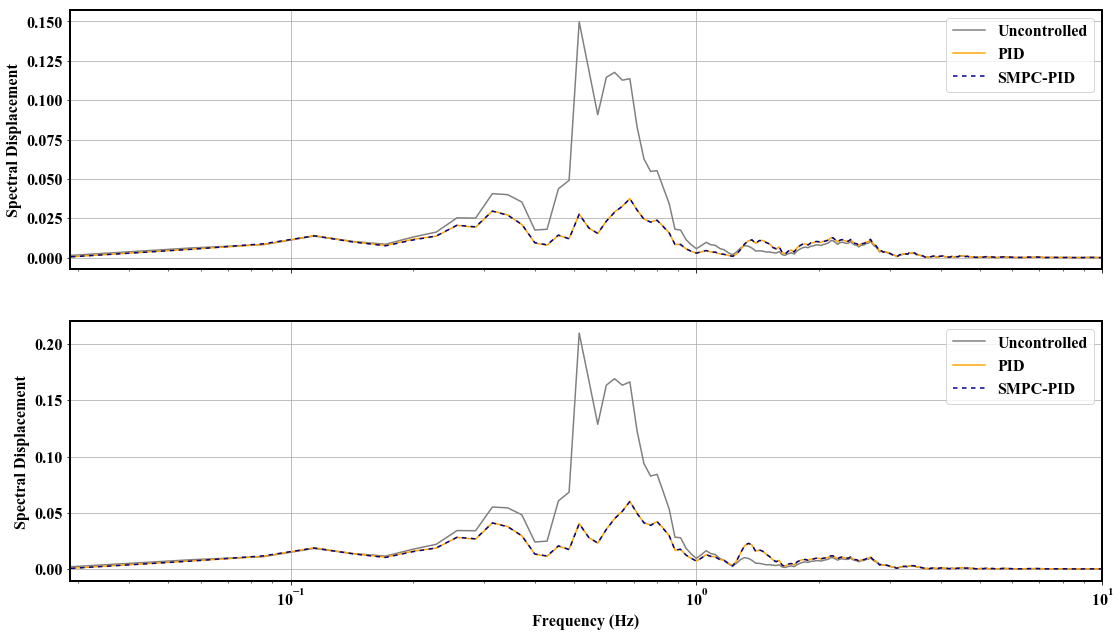

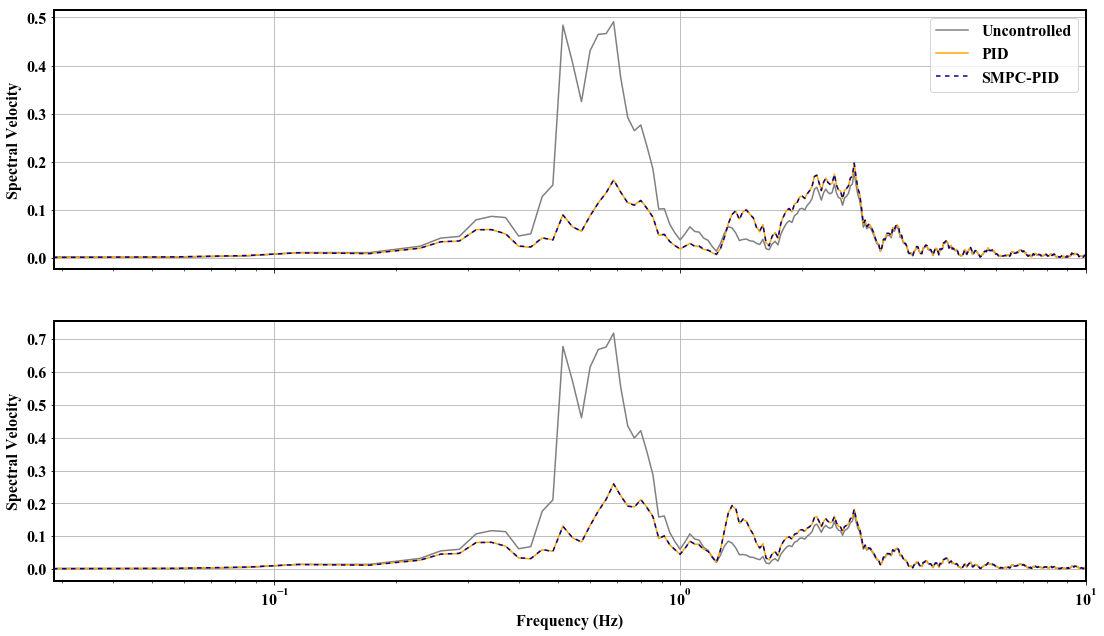

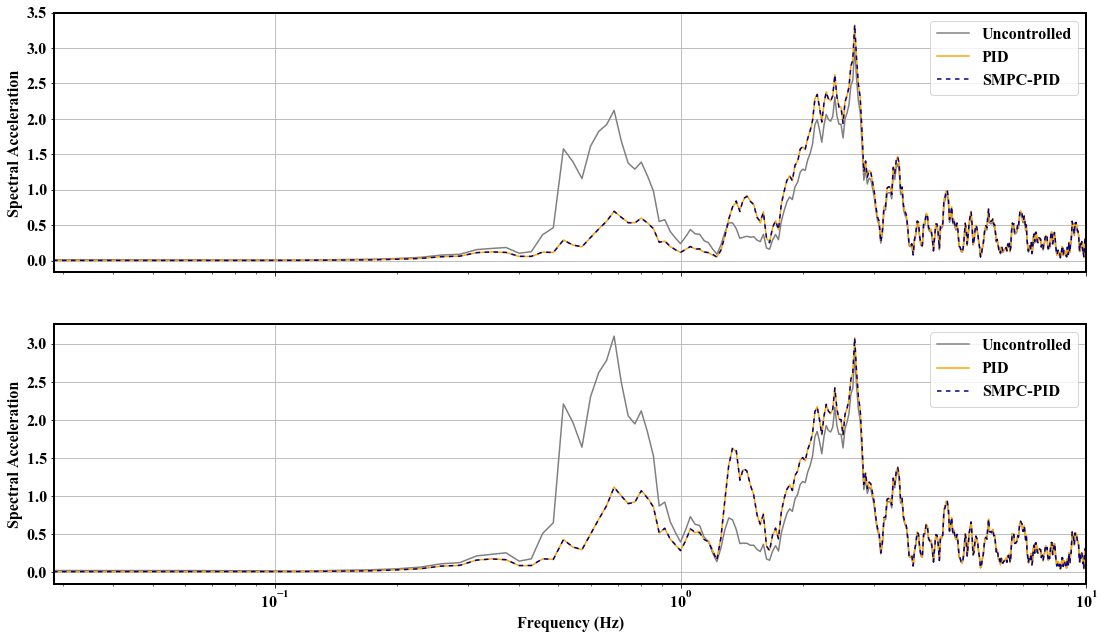

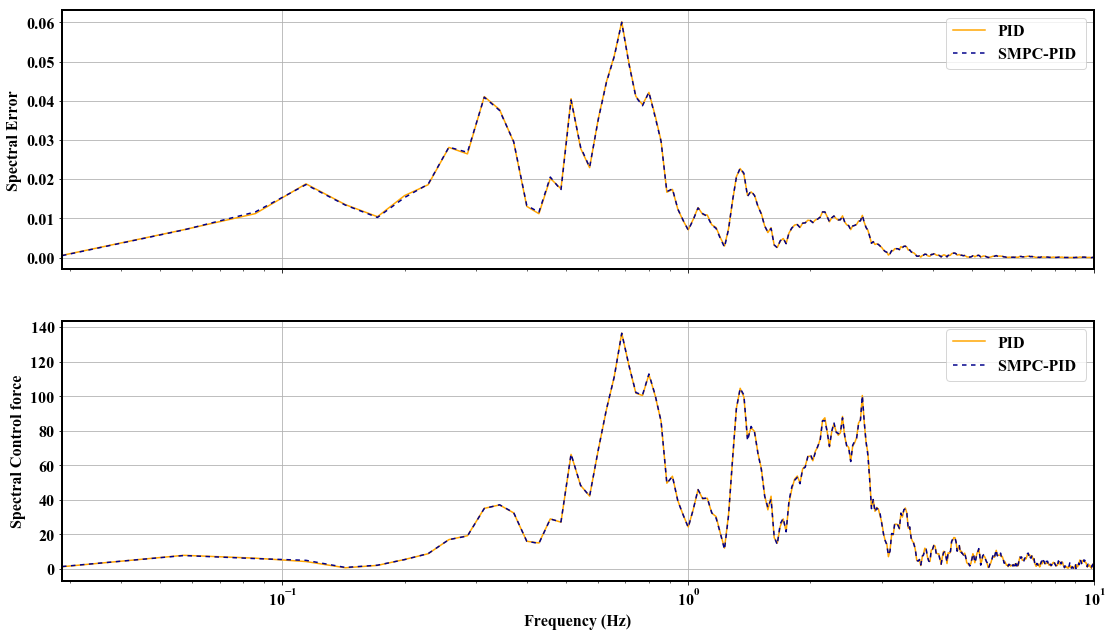

In [4]:
from SecureNewmark_PID import *

Tf = 35 # Simulation time
dt = 0.008 # time step

#base acceleration
#ddxg = np.ones(int(Tf/dt))  # step disturbance
#ddxg = ddxg_el(Tf,dt)           # el centro ground acceleration
#ddxg = ddxg_Tabas(Tf,dt)           # TABAS ground acceleration
ddxg = ddxg_Loma(Tf,dt)         # Loma prieta ground acceleration
#system parameters
M=np.array([[100,0],[0,50]]) # Mass matrix
K=np.array([[4000,-2000],[-2000,2000]]) # Stiffness matrix
ndof=2 # DOF
alpha = 1.5 # Hyperparameter using for damping matrix 

#controller parameters
kp = 50#800#1.9e+03 # Proportional gain
ki = 450#200#1.39e+03 # Integral gain
kd = 550#200#178   # Derivative gain
r = 0 #refference input

# crypto parameters
F=GF(next_prime(2^64)) #finite field
server=4 # number of computing servers
t=1 #shamir threshold 
scale=8 # A/D and D/A Accuracy

resp=Newmark_PID(F,server,t,scale,M,alpha,K,r,kp,ki,kd,0,0,dt,Tf,ndof,ddxg)

In [24]:
import numpy as np
f1shares=np.array(Newmark_PID.f1conts_shares)
np.shape(f1shares)
server1_f1shares=f1shares[:,0]
server1_f1shares=f1shares[:,1]
server1_f1shares=f1shares[:,2]

(4374,)

In [25]:
Newmark_PID.f1conts
f1shares
np.shape(Newmark_PID.f1conts)

(4375,)

In [9]:
from shamirscheme import *
x=np.array([1535315888513527887, 3070631776683205774, 4605947664852883661])
scale=8
n=3
F=GF(next_prime(2^64))
r=basispoly(F,n)
rec(F,x,r,scale)

3.4385

In [14]:
fold=open('results.txt','w')
fold.write(str(Newmark_PID.disp1))
fold.close()

In [3]:
from scipy.io import savemat
a = np.arange(20)

s=np.array([1,2, 3])
s=np.asarray(s)
type(s)
#savemat("matlab_matrix.mat", s)

<class 'numpy.ndarray'>

In [5]:
type(Newmark_PID.f1conts_shares)
np.

<class 'numpy.ndarray'>